# Palmer Penguins Morphological Clustering 🐧
**Author:** Sahel Sepehri


This project explores whether morphological measurements can reveal natural biological structure among penguin species using unsupervised learning techniques.

**Dataset**  
- Palmer Penguins Database (from Seaborn):  
- 344 samples  
- 7 features: species, island, bill_length_mm, bill_depth_mm, flipper_length_mm, body_mass_g, sex
- 3 species: Adelie, Chinstrap, and Gentoo.


**What I did for this project** :
- EDA
- Island-level ecological analysis,
- Feature scaling
- KMeans clustering
- PCA visualization
- Biological interpretation of cluster differences.


---


# Step Ⅰ
## Importing Required Libraries

In [44]:
# Import necessary libraries

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['figure.dpi'] = 100                         
plt.rcParams['font.size'] = 12   
               

# Step Ⅱ
## Load the dataset

*   The Palmer Penguins dataset is built into Seaborn, so we can load it with a single line.




In [8]:
# Load the dataset directly from Seaborn
penguins = sns.load_dataset("penguins")

# Step Ⅲ
## Exploratory Data Analysis (EDA)
This section includes:
- Data inspection
- Descriptive statistics
- Data Cleaning
- Visualization of relationships

### 1. Data Inspection

Preview the data with head() :

In [14]:
print("First 5 rows of the dataset:")
penguins.head()

First 5 rows of the dataset:


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [6]:
print("Dataset shape:", penguins.shape)

Dataset shape: (344, 7)


The dataset has 344 samples and 7 columns (features).


---

Proportion of Classes with value_counts() :

In [89]:
print("\nNumber of penguins per species:")
print(penguins['species'].value_counts())


Number of penguins per species:
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64


---

### 2. Descriptive Statistics

Data Types & Missing Values with info() :

In [22]:
print("\nDataset information:")
print(penguins.info())


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB
None


Some columns contain missing values, including bill_length_mm, bill_depth_mm, flipper_length_mm, body_mass_g, and sex.

---

In [19]:
penguins.describe() # before data cleaning

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


We can observe several statistical measures for the numerical features, including count, mean, first quartile (25%), median (50%), third quartile (75%), minimum, maximum, and standard deviation.

-----------------

### 3. Data Cleaning

- There are only a small number of missing values (NaN) in the dataset.  
- Since the number of missing records is very small, we can remove those rows to simplify the analysis.

In [24]:
# Check missing values in each column
penguins.isna().sum()


species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [11]:
# Remove rows that contain missing values
penguins_clean = penguins.dropna().copy()


# Verify that missing values are removed
penguins_clean.isna().sum()


species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

In [12]:
# Check dataset shape before and after cleaning
print("Original dataset shape:", penguins.shape)
print("Clean dataset shape:", penguins_clean.shape)

Original dataset shape: (344, 7)
Clean dataset shape: (333, 7)


Preview the data after cleaning :

In [17]:
penguins_clean.head()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


In [18]:
penguins_clean.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,333.000000,333.000000,333.000000,333.000000
mean,43.992793,17.164865,200.966967,4207.057057
std,5.468668,1.969235,14.015765,805.215802
min,32.100000,13.100000,172.000000,2700.000000
25%,39.500000,15.600000,190.000000,3550.000000
50%,44.500000,17.300000,197.000000,4050.000000
75%,48.600000,18.700000,213.000000,4775.000000
max,59.600000,21.500000,231.000000,6300.000000


---

# Step Ⅳ
In this section we explore the main morphological measurements in the Palmer Penguins dataset.  
We study variation between species and identify structure that will be useful for clustering later.

### 1. Scatter Plot - Bill Length vs Flipper Length

This scatter plot examines the relationship between bill length and flipper length.  
If species appear in separate regions of this space, it suggests natural structure in morphology.


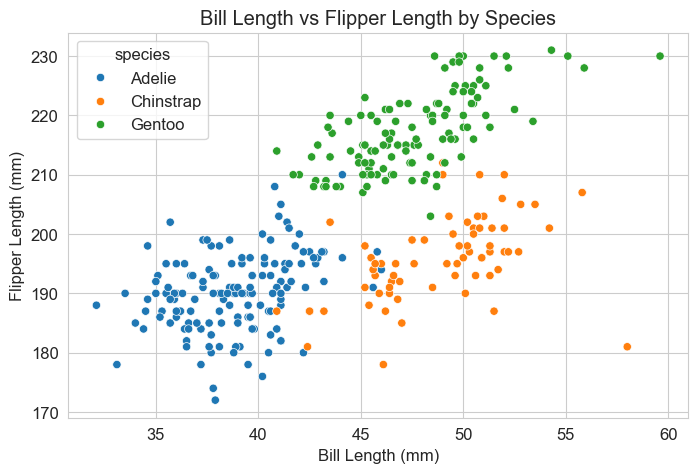

In [42]:
sns.scatterplot(
    data=penguins_clean,              
    x='bill_length_mm',               
    y='flipper_length_mm',           
    hue='species'          # Color (hue): species (so we can see if different penguin species look different)                  
)

# Add title and axis labels
plt.title('Bill Length vs Flipper Length by Species')
plt.xlabel('Bill Length (mm)')
plt.ylabel('Flipper Length (mm)')

# Save the plot as an image file
plt.savefig('simple_scatter_penguins.png', dpi=150, bbox_inches='tight')

# Show the plot
plt.show()

### Interpretation of the Scatter Plot

- Adelie penguins generally have shorter bills and shorter flippers, forming a cluster in the lower-left area of the plot.
- Chinstrap penguins tend to have longer bills than Adelie, while their flipper length remains relatively similar.
- Gentoo penguins stand out with much longer flippers and larger overall size, separating them clearly from the other species.
Overall, the scatter plot highlights clear morphological differences between penguin species, with Gentoo appearing noticeably larger, mainly due to their longer flippers.
---

### 2. Pairplot of Measurements (See All Variables Together)

- The pairplot visualises pairwise relationships between measurements. It shows relationships between all numeric columns at once. 
- It helps check if species naturally separate in feature space.

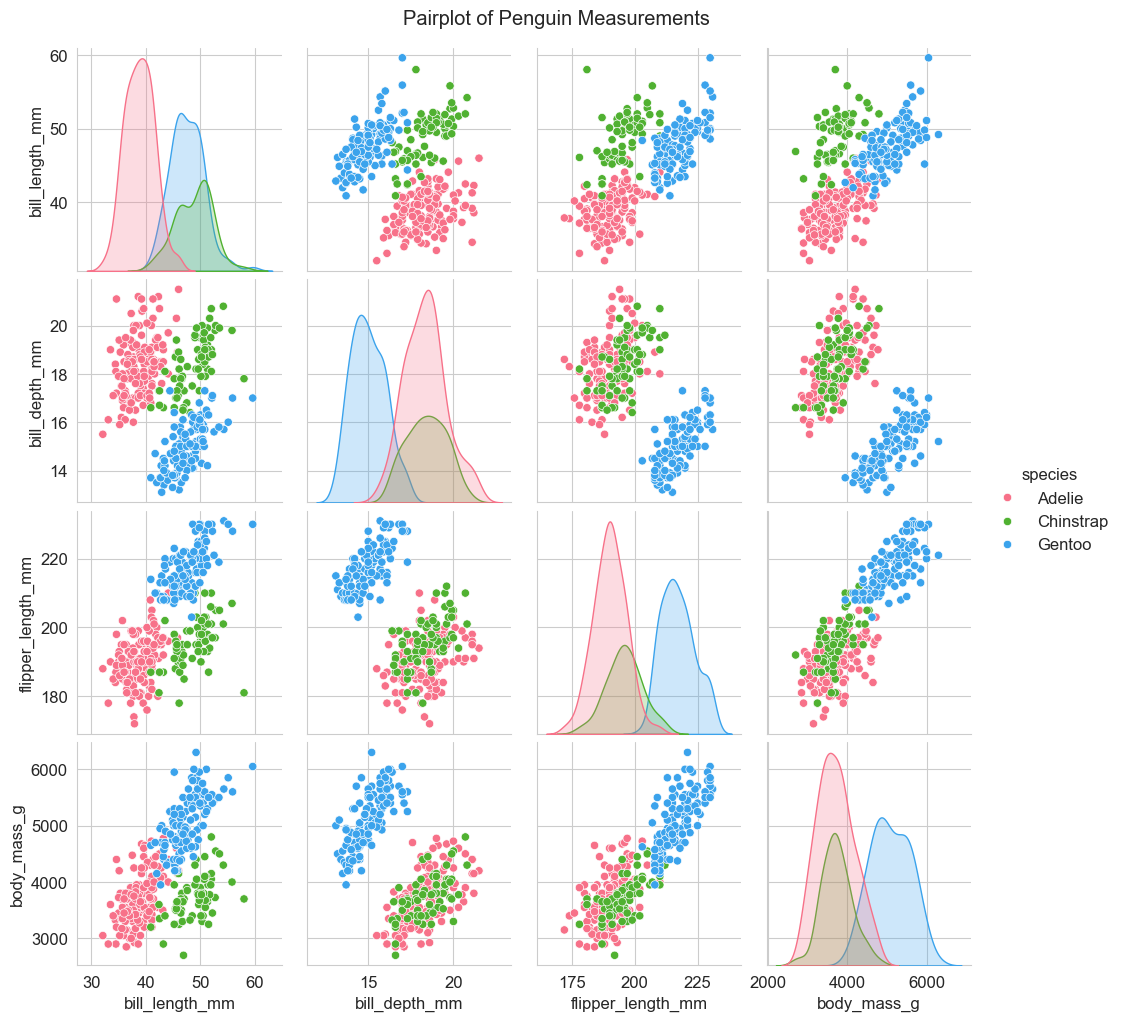

In [ ]:
sns.pairplot(
    penguins_clean,
    hue='species',
    palette='husl'
)

# y=1.02 moves the title up toward the top of the figure; lower values move it downward
plt.suptitle('Pairplot of Penguin Measurements', y=1.02)
plt.savefig('Pairplot_Penguin_Measurements.png', dpi=150, bbox_inches='tight')

plt.show()


### Interpretation of the Pairplot

- Gentoo penguins form a clearly separated group in several feature combinations, especially in flipper length and body mass, indicating that this species is generally larger than the others.
- Adelie and Chinstrap penguins show considerable overlap in many plots, meaning their measurements are more similar to each other.
- However, some separation appears in bill depth, where Chinstrap tends to have slightly deeper bills compared to Adelie.
- A clear positive relationship between flipper length and body mass can be observed across species, suggesting that penguins with longer flippers tend to be heavier.

### 3. Boxplot - Body Mass by Species and Sex

This boxplot shows differences in body mass across species and sexes.  
It illustrates both interspecies variation and sexual dimorphism.


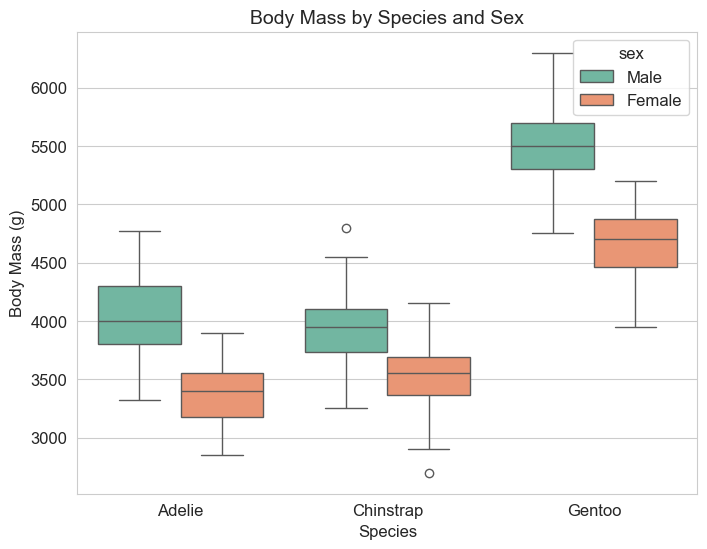

In [37]:
sns.boxplot(
    data=penguins_clean,
    x='species',
    y='body_mass_g',
    hue='sex',
    palette='Set2'
)

plt.title('Body Mass by Species and Sex', fontsize=14)
plt.xlabel('Species', fontsize=12)
plt.ylabel('Body Mass (g)', fontsize=12)
plt.savefig('simple_boxplot_body_mass.png', dpi=150)
plt.show()

### Interpretation of the Boxplot

- Male penguins are consistently heavier than females within each species.
- Gentoo shows the highest body mass overall with a median around 5000 to 5500 g and relatively tight variation.
- Adelie has the lowest body mass with a median close to 3500 to 4000 g.
- Chinstrap falls in the middle, heavier than Adelie but lighter than Gentoo.
- This pattern is consistent with what appeared in the scatter plots and pairplot, reinforcing the species level size differences.

---

### 4. Violin Plot – Distribution of Bill Depth

- This violin plot shows the distribution of bill depth for each species and sex.  
- Bill depth relates to feeding strategies and ecological differences.
- It combines a boxplot (inside) with a smooth density shape (violin).  



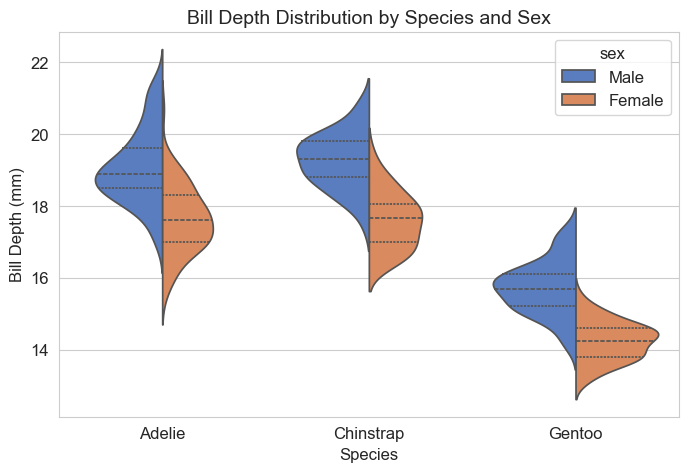

In [46]:
sns.violinplot(
    data=penguins_clean,
    x='species',                    # groups on x-axis
    y='bill_depth_mm',              # values on y-axis
    hue='sex',                      # different colors for male/female
    split=True,                     # split violin for male/female side by side
    palette='muted',                # soft colors
    inner='quartile'                # show quartiles inside the violin
)

plt.title('Bill Depth Distribution by Species and Sex', fontsize=14)
plt.xlabel('Species', fontsize=12)
plt.ylabel('Bill Depth (mm)', fontsize=12)


plt.savefig('simple_violin_bill_depth.png', dpi=150, bbox_inches='tight')


plt.show()

### Interpretation of the Violin Plot

- Wider sections indicate where more penguins fall within that bill depth range.
- Gentoo generally has deeper bills than the other species (its violin is shifted higher).
- Adelie and Chinstrap have some overlap, but Chinstrap usually has slightly deeper bill depths than Adelie on average.
- The shape suggests Gentoo shows less variation in bill depth compared to Adelie.
- Across species, males tend to have slightly deeper bills than females, although the difference is not huge.
---

### 5. Correlation Heatmap

- This heatmap summarises correlations between the four main morphological measurements.  
- Correlation patterns show which measurements capture similar structure.
- This heatmap shows how strongly the numeric measurements are related to each other.  


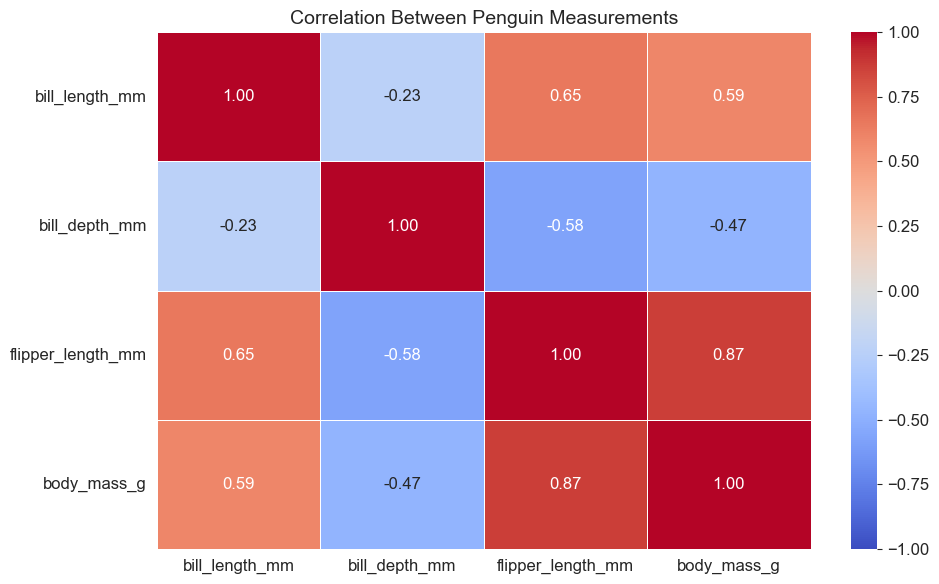

In [47]:
numeric = penguins_clean[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']]

# Calculate correlation
corr = numeric.corr()

plt.figure(figsize=(10,6))
sns.heatmap(
    corr,
    annot=True,           # show numbers inside cells
    cmap='coolwarm',      # red-blue color scheme
    vmin=-1, vmax=1,      # range from -1 to +1
    fmt='.2f',            # two decimal places
    linewidths=0.5        # thin lines between cells
)

plt.title('Correlation Between Penguin Measurements', fontsize=14)
plt.tight_layout()
plt.savefig('simple_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretation of  the Heatmap

- Red shows positive correlation (when one measurement increases, the other also increases).

- Blue shows negative correlation.

- Values close to 1 or -1 indicate a strong relationship.

- Flipper length and body mass show a strong positive correlation (~0.87), meaning penguins with longer flippers tend to be heavier, which makes biological sense.

- Bill length and bill depth have a weak negative correlation, suggesting that longer bills do not necessarily mean deeper bills, and in some species the relationship goes slightly in the opposite direction.
---

# Step Ⅴ

## Island Level Analysis

The Palmer Penguins dataset contains observations from three islands in Antarctica:

- Biscoe
- Dream
- Torgersen

In this section we investigate whether penguin morphology varies across islands.  
- Environmental differences such as food availability and habitat conditions may influence body size and shape.
- Understanding these patterns provides ecological context before applying clustering.



In [48]:
# Check island distribution
penguins_clean['island'].value_counts()

island
Biscoe       163
Dream        123
Torgersen     47
Name: count, dtype: int64




--------------

## 1. Species Distribution Across Islands

- This plot shows how penguin species are distributed across the three islands.  
- Different species dominate different islands, which may influence observed morphological patterns.


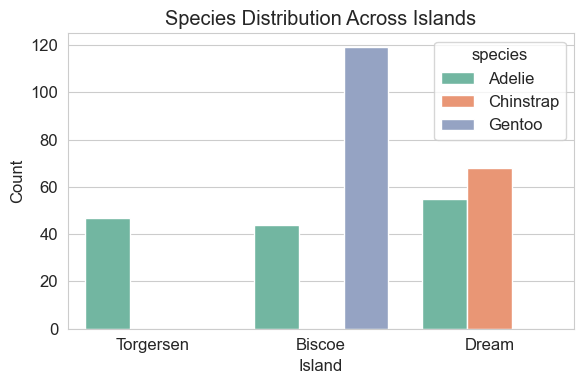

In [83]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=penguins_clean,
    x='island',
    hue='species',
    palette='Set2'
)

plt.title('Species Distribution Across Islands')
plt.xlabel('Island')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('plot_species_by_island.png', dpi=150)

plt.show()

### Interpretation of the Count plot
- Chinstrap and Gentoo penguins are island-specific species.
- Gentoo are found only on Biscoe Island, while Chinstrap appear only on Dream Island.
- This suggests that each species may prefer specific environmental conditions or habitats.

- Adelie penguins are the only species found on all three islands. This indicates that Adelie are more adaptable to different environments and can be considered an ecological generalist.

- On Biscoe and Dream Islands, two species live together. Adelie and Gentoo coexist on Biscoe, while Adelie and Chinstrap coexist on Dream. This makes these islands interesting for studying how species share resources.

- Torgersen Island hosts only Adelie penguins. No other species are observed there, making it a clean and simple environment for studying Adelie without interference from other species.

---

### 2. Body Mass Distribution by Island

- Body mass can vary depending on ecological conditions.  
- This boxplot compares penguin body mass across islands.

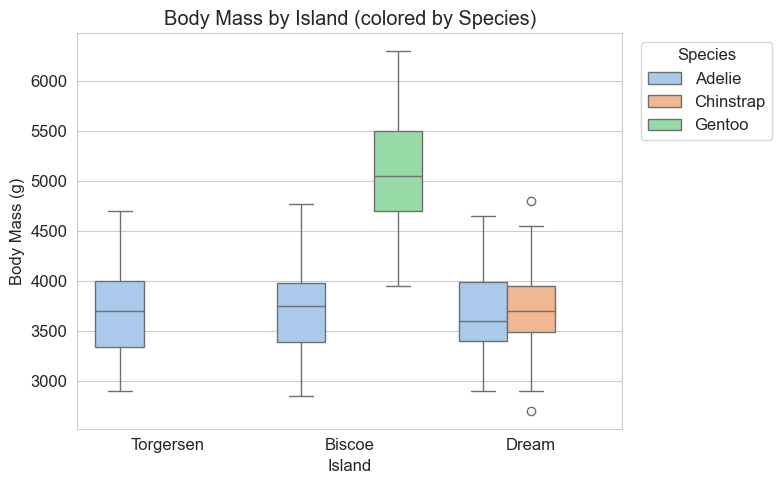

In [54]:
sns.boxplot(
    data=penguins_clean,
    x='island',
    y='body_mass_g',
    hue='species',
    palette='pastel'
)

plt.title('Body Mass by Island (colored by Species)')
plt.xlabel('Island')
plt.ylabel('Body Mass (g)')
plt.legend(
    title='Species',
    bbox_to_anchor=(1.02, 1), # move legend slightly outside the plot area
    loc='upper left'          # anchor legend's upper-left corner
)
 
plt.tight_layout()
plt.savefig('plot_bodymass_island_species.png', dpi=150)
plt.show()


### Interpretation of the Box Plot

- Gentoo penguins on Biscoe Island are significantly heavier than the other two species. Their median body mass is much higher, mostly staying above 4500g, while others stay below that.

- Adelie penguins show a very consistent body mass distribution across all three islands (Biscoe, Dream, and Torgersen). This suggests that their physical size is not heavily influenced by the specific island environment they live in.


- On Dream Island, the body mass ranges for Adelie and Chinstrap are very similar. This means that while weight is a great feature to identify a Gentoo, it is not enough to distinguish between an Adelie and a Chinstrap on Dream Island. We will need other features (like bill length) for that.

- On Biscoe Island, there is a clear gap in body mass between Adelie and Gentoo. This suggests a clear ecological niche separation based on size on this island.
---

### 3. Flipper Length Across Islands

- Flipper length is associated with swimming ability and body size.  
- Comparing islands may reveal ecological or species driven differences.

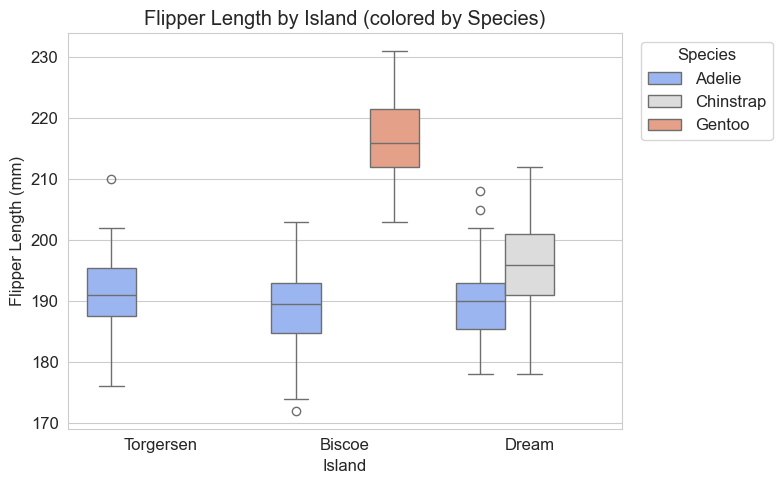

In [ ]:

sns.boxplot(
    data=penguins_clean,
    x='island',
    y='flipper_length_mm',
    hue='species',
    palette='coolwarm'
)

plt.title('Flipper Length by Island (colored by Species)')
plt.xlabel('Island')
plt.ylabel('Flipper Length (mm)')

plt.legend(title='Species', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('plot_flipper_island_species.png', dpi=150)
plt.show()



### Interpretation of the Box Plot

- Gentoo penguins on Biscoe Island have the longest flippers among all species. Their flipper length distribution is significantly higher than the others.

- Adelie penguins appear on all three islands and their flipper length remains relatively consistent across Biscoe, Dream, and Torgersen. This suggests that their body structure is stable across different environments.

- On Dream Island, Chinstrap penguins generally have slightly longer flippers than Adelie. However, there is still some overlap between the two species.

- Only Adelie penguins appear on Torgersen Island, and their flipper length distribution is similar to Adelie on the other islands.

---

### 4. Morphological Relationship by Island - Scatter Plot

- This scatter plot shows the relationship between bill length and flipper length, colored by island.  
- It helps reveal whether islands show different morphological clusters.

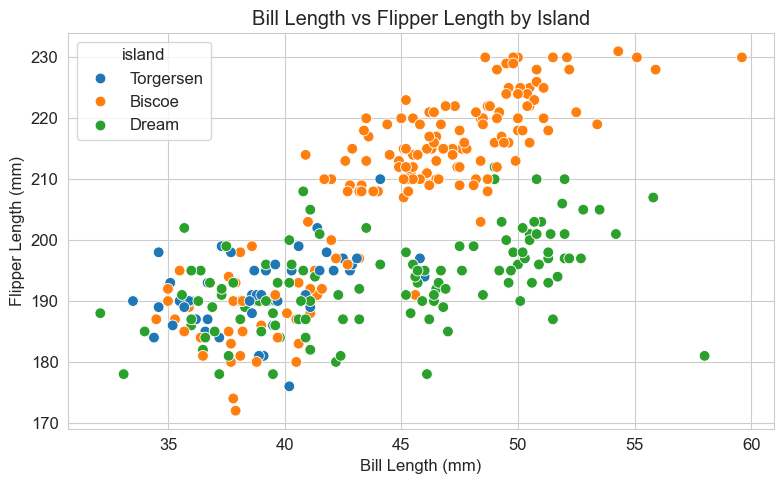

In [59]:

sns.scatterplot(
    data=penguins_clean,
    x='bill_length_mm',
    y='flipper_length_mm',
    hue='island',
    s=60 # controls the size of the scatter points
)

plt.title('Bill Length vs Flipper Length by Island')
plt.xlabel('Bill Length (mm)')
plt.ylabel('Flipper Length (mm)')
plt.tight_layout()
plt.savefig('plot_scatter_island.png', dpi=150)

plt.show()

### Interpretation of the Scatter Plot

1. Biscoe Island

Points from Biscoe Island cluster mostly in the top-right area (high bill length and high flipper length). This is consistent with Gentoo penguins, which are larger and heavier in general.

2. Dream Island

Dream Island points are in the middle range of bill length and flipper length. This pattern corresponds mostly to Chinstrap and Adelie penguins, whose body sizes are intermediate.

3. Torgersen Island 

The Torgersen Island cluster sits at the lower-left corner of the plot, showing small bill and flipper sizes. This confirms that only Adelie penguins inhabit this island.

- There’s a clear size gradient from Torgersen → Dream → Biscoe, reflecting an ecological and morphological separation of species across islands.
---

# Step Ⅵ
## Unsupervised Learning (Clustering Analysis)


### Discovering Natural Penguin Groups

In this section, we explore whether penguins can be grouped into natural clusters based purely on their morphological measurements.

Instead of using the species label, we apply an unsupervised learning algorithm (KMeans) to discover hidden structures in the data.

Features used for clustering:
- bill_length_mm
- bill_depth_mm
- flipper_length_mm
- body_mass_g


Before running KMeans, all numerical features will be standardized so that differences in scale do not bias the clustering results.
This ensures that each feature contributes equally to the distance calculations.


### 1. Feature Scaling

- KMeans groups samples by measuring how close they are to each other.
- It uses the regular distance between points (Euclidean distance),
- We scale the data before KMeans because KMeans relies on distance metrics. 
- Features with larger scales would dominate and bias the clustering process. 
- By standardizing the features, we make all variables contribute equally to the distance.

In [61]:

# Select numerical features for clustering
features = penguins_clean[['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g']]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# Convert scaled array back to DataFrame for easier interpretation
X_scaled = pd.DataFrame(X_scaled, columns=features.columns)


---

### 2. Elbow Method (Choosing k) - Determining the Optimal Number of Clusters

- The Elbow Method helps determine the optimal number of clusters.
- It plots the number of clusters (k) against inertia (within-cluster variance).
- The optimal k is typically where the decrease in inertia starts to slow down, forming an “elbow” in the curve.

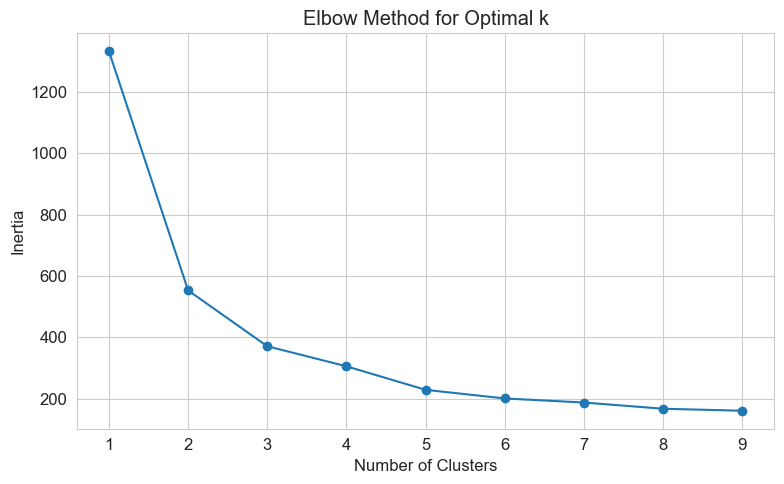

In [63]:
# Store inertia values for different k
inertia = []

# Test k values from 1 to 9
K_range = range(1, 10)

for k in K_range:
    # Create KMeans model with k clusters
    kmeans = KMeans(n_clusters=k, random_state=42)
    
    # Fit model on scaled data
    kmeans.fit(X_scaled)
    
    # Save the inertia (how compact clusters are)
    inertia.append(kmeans.inertia_)

# Plot k vs inertia
plt.plot(K_range, inertia, marker='o')

plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.tight_layout()
plt.savefig("elbow_method.png", dpi=150)
plt.show()




- In the Palmer Penguins dataset, the elbow method usually suggests k = 3, which aligns with the presence of three penguin species (Adelie, Chinstrap, and Gentoo).

- As the number of clusters increases, inertia always decreases because data points are assigned to closer cluster centers. However, after a certain point, the reduction in inertia becomes much smaller.

- This point, known as the "elbow", represents a good balance between model simplicity and cluster compactness.


---

### 3. Applying KMeans Clustering

- Based on the elbow method, we select k = 3 clusters.
- The KMeans algorithm will group penguins based on their standardized physical measurements, without using the species label. This allows us to see whether the natural clusters in the data align with the true species.

In [64]:
# Initialize KMeans with 3 clusters (based on the elbow method)
kmeans = KMeans(n_clusters=3, random_state=42)

# Fit KMeans on the scaled features and get the cluster labels
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to the original cleaned dataframe
penguins_clean['cluster'] = clusters

# Step Ⅶ
## Visualizing Clusters using PCA

- Since the dataset has multiple features, it is difficult to visualize clusters directly.
- Therefore, we apply Principal Component Analysis (PCA) to reduce the feature space to two principal components.
- This allows us to visualize the cluster structure in a 2D plot.
- PCA is sensitive to the scale of features. Therefore, we apply PCA on the standardized data so that all features contribute equally to the principal components.



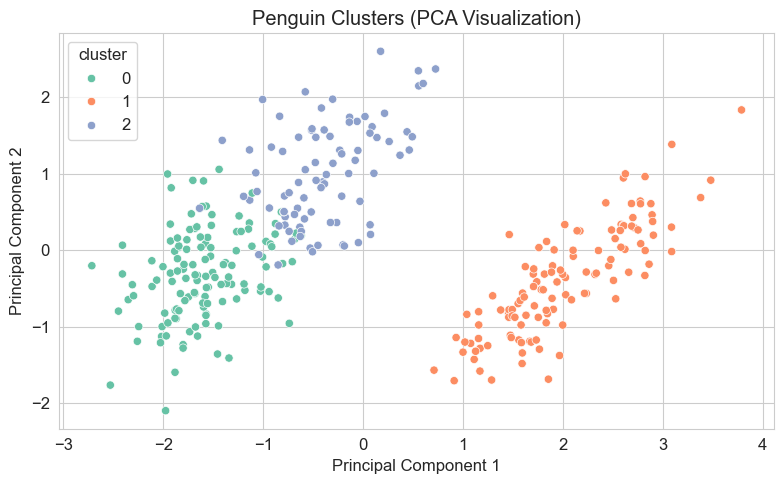

In [66]:
# Reduce the scaled features to 2 components for visualization
pca = PCA(n_components=2)

# Fit PCA on scaled data and transform it
X_pca = pca.fit_transform(X_scaled)

# Add principal components to the dataframe
penguins_clean['PC1'] = X_pca[:, 0]
penguins_clean['PC2'] = X_pca[:, 1]

sns.scatterplot(
    data=penguins_clean,
    x='PC1',
    y='PC2',
    hue='cluster',
    palette='Set2'
)

plt.title("Penguin Clusters (PCA Visualization)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.tight_layout()
plt.savefig("penguin_clusters_pca.png", dpi=150)

plt.show()



### Interpretation of the Scatter Plot


- The scatter plot shows the KMeans clusters projected onto the first two principal components.
- Each point represents a penguin, and colors indicate the assigned cluster.
- The clusters are reasonably well separated in the PCA space, suggesting that KMeans was able to identify meaningful structure in the data.
- Some overlap between clusters is expected, as PCA reduces higher-dimensional information into two components.

Overall, this visualization confirms that the clustering is not random and that the selected features capture relevant differences between penguins.


---

# Step Ⅷ
## Cluster Interpretation
- To understand the biological meaning of the clusters identified by KMeans, we analyze the mean values of morphological features for each group. This allows us to interpret what distinguishes the clusters in biological terms.

In [88]:
numeric_cols = penguins_clean.select_dtypes(include=['float64','int64']).columns

penguins_clean.groupby("cluster")[numeric_cols].mean()



,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,PC1,PC2
cluster,,,,,,
0,38.276744,18.121705,188.627907,3593.798450,-1.597030,-0.304279
1,47.568067,14.996639,217.235294,5092.436975,2.012976,-0.394028
2,47.662353,18.748235,196.917647,3898.235294,-0.394439,1.013427


### Interpretation of the Cluster Features

- Cluster 1 (Gentoo): This group is characterized by longer flippers and the highest body mass. These features are typical of Gentoo penguins, the largest species in this dataset, which are adapted for deep diving and efficient swimming.


- Cluster 0 (Adelie): This cluster represents smaller-bodied penguins with the lowest average body mass and shorter flipper lengths. These characteristics align with the Adelie species.

- Cluster 2 (Chinstrap): This group shows a distinct profile, often characterized by moderate body size but relatively deeper or longer bills compared to Adelies, which is a key trait of the Chinstrap species.



The clustering results align closely with the known biological differences between the three species. This confirms that features like flipper length and body mass are strong indicators for species differentiation in penguins.

---

# Step Ⅸ
## Cluster vs Species Comparison

Goal: Evaluate whether the clusters discovered by KMeans correspond to the actual penguin species.



### 1. Crosstab Analysis

In [81]:
pd.crosstab(penguins_clean['cluster'], penguins_clean['species'])


species,Adelie,Chinstrap,Gentoo
cluster,,,
0,124,5,0
1,0,0,119
2,22,63,0


This table shows:

- how many samples of each species appear in each cluster
- whether the clustering algorithm successfully separated the species


- To evaluate the quality of clustering, we compare the discovered clusters with the true species labels.

- If each cluster mostly contains a single species, it indicates that the morphological features (bill length, bill depth, flipper length, and body mass) provide strong signals that allow the algorithm to separate penguin species effectively.

- A strong alignment between clusters and species suggests that the unsupervised algorithm was able to uncover meaningful biological groupings from the data.


Since KMeans is an unsupervised algorithm, the species labels were not used during training. The comparison is performed only for evaluation purposes.

---

### 2. Visualization

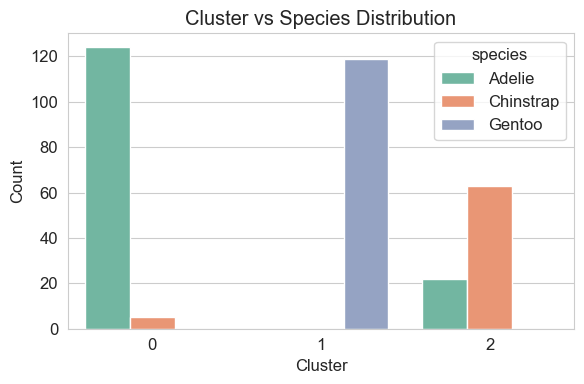

In [82]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=penguins_clean,
    x='cluster',
    hue='species',
    palette='Set2'
)

plt.title("Cluster vs Species Distribution")
plt.xlabel("Cluster")
plt.ylabel("Count")

plt.tight_layout()
plt.savefig("cluster_vs_species.png", dpi=150)

plt.show()


### Interpretation of the Count Plot

- This count plot visualizes how well the KMeans clusters align with the actual penguin species:
- Each cluster is predominantly composed of a single species, indicating that the algorithm successfully identified the natural groupings based on morphological features.
- The small amount of overlap between some species (likely between Adelie and Chinstrap) suggests that they share similar physical traits, making them slightly harder to distinguish than Gentoo penguins.
  
The model performed exceptionally well, proving that body mass and flipper/bill measurements are strong biological indicators for species classification.

---

# Step Ⅹ
### Interpretation

The comparison between clusters and actual species shows that the KMeans algorithm successfully recovered the natural biological structure of the dataset.

Most penguins belonging to the same species fall into the same cluster. This indicates that morphological measurements strongly reflect species differences.

Why does KMeans still find three groups without using species labels?
1. Real biological differences exist

Penguin species differ naturally in body size and shape:

Adelie penguins have shorter beaks and smaller bodies
Gentoo penguins are heavier and have longer flippers
Chinstrap penguins show distinct bill characteristics
These differences are real and consistent, not artificial.

2. KMeans captures spatial structure

KMeans groups data points based on their positions in feature space.

When the data naturally forms separate groups, the algorithm can detect them easily.

3. Morphological features are strong signals

Differences in diet, habitat, and foraging behavior lead to consistent variations in body mass, flipper length, and bill measurements. These traits strongly encode species identity.

4. PCA confirms the clustering

The PCA visualization shows three clearly separated groups.

This suggests that the data itself is naturally structured into three clusters.

In other words, nature has already grouped the penguins.

KMeans does not create these groups, it only discovers them.

---


# Step Ⅺ
### Conclusion

- KMeans clustering successfully rediscovered the three natural penguin species using only morphological features.

- The separation between clusters is mainly driven by flipper length and body mass, which reflect ecological and evolutionary adaptations.

- This project demonstrates that unsupervised learning can uncover meaningful biological patterns even when no labels are provided during training.
---

# Step Ⅻ
### Upcoming Improvements
Future improvements for this project could include:

- Comparing KMeans with other clustering algorithms such as DBSCAN or Hierarchical Clustering
- Evaluating cluster quality using metrics like Silhouette Score
- Including additional environmental or behavioral features if available
- Applying the same pipeline to other biological datasets

---

# Step XIII
### What I Learned and Personal Thoughts
- Through this project, I learned how unsupervised learning algorithms explore structure hidden inside data.

- I gained a deeper understanding of why feature scaling is critical for distance-based algorithms and how PCA helps interpret high-dimensional data.

- This project helped me move beyond simply running models and focus on interpretation, reasoning, and biological meaning. It strengthened my confidence in explaining machine learning concepts clearly and intuitively.
---

## References

This project uses the built‑in penguins dataset from Seaborn. 
All analyses were performed using standard Python libraries.


- Seaborn Penguins Dataset (built‑in): https://seaborn.pydata.org
- Scikit‑learn User Guide: https://scikit-learn.org
- Seaborn Documentation: https://seaborn.pydata.org/tutorial.html
- Pandas Documentation: https://pandas.pydata.org
- Matplotlib Documentation: https://matplotlib.org

 Some explanations and text refinements in this notebook were assisted by AI tools for clarity and language improvement.

By :Sahel Sepehri
- sahelsepehri99@gmail.com
- https://github.com/sahelsepehri